lokale csv 02Apple_Offline.csv wird geladen...
History Startwert registriert: 2015-01-02


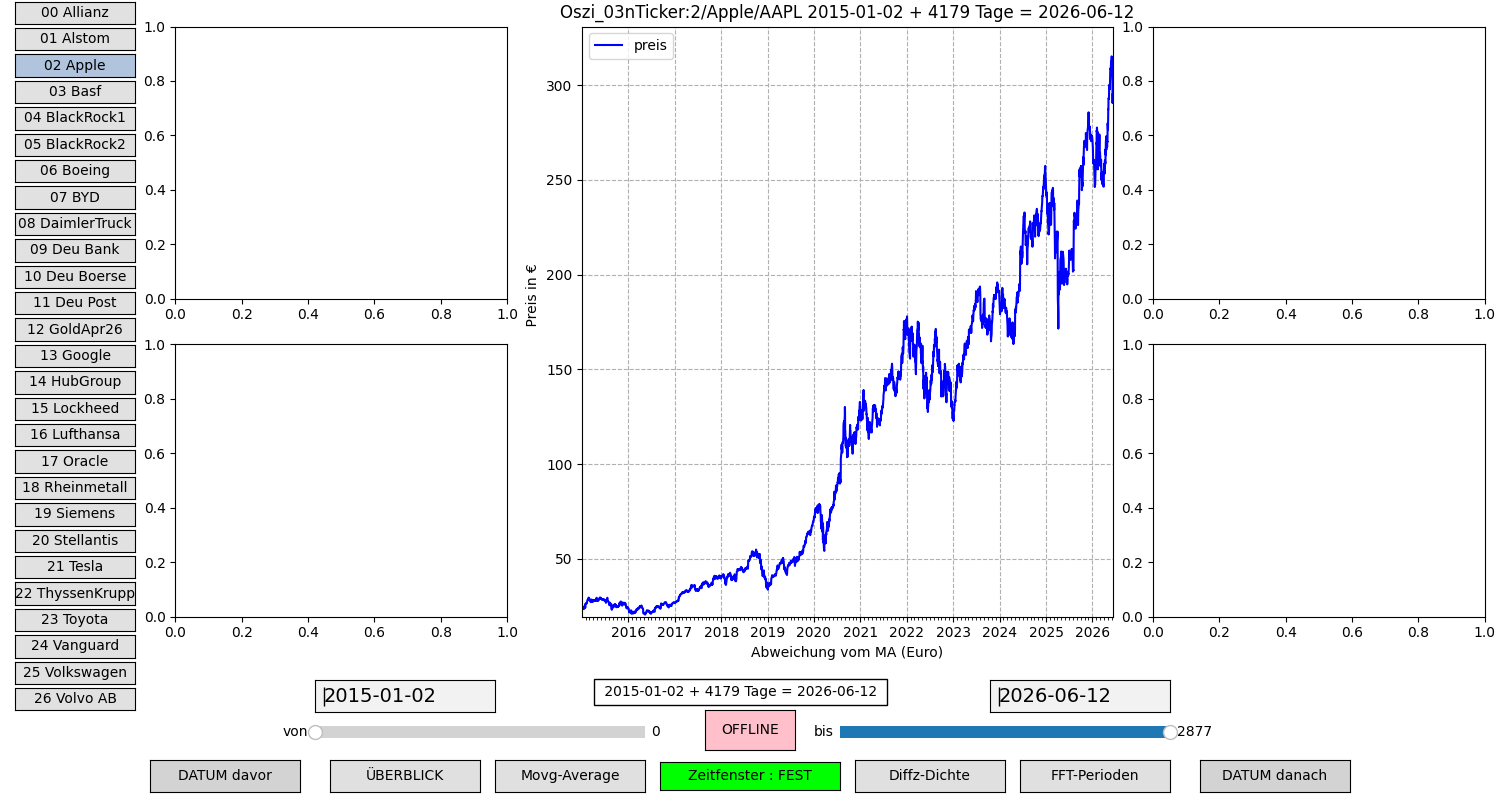

In [1]:
# BoersenOszi.py 16/28-06-2026 18h25 998.Z Version 03 R.Wu_GastH_Nr178854
# Alle Importe
import math
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
import statsmodels.api as sm  # pip install statsmodels (Lilliefors)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.widgets import Slider, Button, TextBox
from datetime import datetime
import os
import csv
import locale
# FENSTER LAYOUT IN MOSAIC-TECHNIK
%matplotlib widget
OSZ='Oszi_03n'
plt.rcParams['toolbar'] = 'None'
layout = [['.','3Win','1Win','1Win','4Win'],['.','2Win','1Win','1Win','5Win'],['.','.','.','.','.']]  # bei Lücke '.']]
breitverh = [0.525] * 1 + [1.25] * 1 + [1] * 2 + [1.25] * 1
hoeheverh = [1] * 2 + [0.5] * 1
# Gesamtgröße not tight but constrained 
fig,axd=plt.subplot_mosaic(layout,figsize=(15,8),gridspec_kw={'width_ratios':breitverh,'height_ratios':hoeheverh},layout='constrained')
# --- FENSTER ---
fig2 = fig
fig3 = fig
fig4 = fig
fig5 = fig
ax = axd['1Win']
ax.set_title('1.Fenster-Börsen-Oszillograph')
ax3 = axd['3Win']
ax2 = axd['2Win']
ax1 = axd['1Win']
ax4 = axd['4Win']
ax5 = axd['5Win']
# ==============================================================================
#     0b    Importe und Lokalzeit über LOCALE aufrufen und speichern
# ==============================================================================
datuhr='_Fig'                          # dummy wenn keine locale-Funktionalitaet
locale.setlocale(locale.LC_TIME, "de_DE")
datu=str(datetime.now())
datuhr=datu[2:4:1]+datu[5:7:1]+datu[8:10:1]+'_'+datu[11:13:1]+'h'+datu[14:16:1]
plt.rcParams['toolbar'] = 'None'
# ==============================================================================
#     01    Projekt VARIABLEN
# ==============================================================================
val_online = 0            # default 1 = Online live, 0 = Offline
val_clr    = 1            # Default 1 = FEST(Zoom behalten), 0 = VAR (Reset)
akt_index       = 2                # Default-Ticker (Standard: 2 = Apple)
yfNAME = "AAPL"                    # Default-Ticker für den Online-Start
offlinecsv = "02Apple_Offline.csv" # Default-Ticker für den Offline-Start
trigger = False                    # start-stop zum Schaubild-zeichnen
ANF_DATUM = "2015-01-02"           # Default-Fenster ANF
END_DATUM = "2026-06-15"           # Default-Fenster END
moving_size = 20                   # Moving-Average-Fenster
preis_linie = 1  # Preis-Linie ein
MAmiw_linie = 0  # MoveAverage aus
FEmiw_linie = 0  # Fenster-MiW aus
diffz_linie = 0  # PreisMA-Dif aus
FFT_Diagram = 0  # Fourier-Spektrum(Log) aus
line_preis = None
trigger = False
df = pd.DataFrame()                # globales DataFrame
# ------------------------------------------------------------------------------
#     02 Ticker-Liste aus CSV-Liste laden
# ------------------------------------------------------------------------------
try: ticker_df = pd.read_csv('Ticker-Liste_alt.csv')
except FileNotFoundError:
    # Default Liste falls Ticker-Liste_alt.csv fehlt
    ticker_liste = """Num,Nam,Tik
00,Allianz,ALV.DE
01,Alstom,AOMD.DE
02,Apple,AAPL
03,Basf,BAS.DE
04,BlackRock1,BR
05,BlackRock2,BLK
06,Boeing,BA
07,BYD,002594.SZ
08,DaimlerTruck,DTG.DE
09,Deu Bank,DB
10,Deu Boerse,DBOEY
11,Deu Post,DHL.DE
12,GoldApr26,GC=F
13,Google,GOOG
14,HubGroup,HUBG
15,Lockheed,LOM.F
16,Lufthansa,LHA.DE
17,Oracle,SOC.SG
18,Rheinmetall,RHM.DE
19,Siemens,SIE.DE
20,Stellantis,STLAM.MI
21,Tesla,TSLA
22,ThyssenKrupp,TKA.DE
23,Toyota,TOYOF
24,Vanguard,VWRL.SW
25,Volkswagen,VOW.DE
26,Volvo AB,VOL1.SG"""
    with open('Ticker-Liste_alt.csv', 'w') as f:
        f.write(ticker_liste)
    ticker_df = pd.read_csv('Ticker-Liste_alt.csv')
# ------------------------------------------------------------------------------
#     03   zeitfenster-history anlegen
# ------------------------------------------------------------------------------
# GANZ OBEN INITIALISIEREN
history_back = []     # Speicher für den "Linksknick" (Zurück)
history_forward = []  # Speicher für den "Rechtsknick" (Vorwärts)
def aktuellen_zustand_sichern():
    # 1. Wir holen uns die nackten Text-Strings direkt von der Matplotlib-Oberfläche
    str_anf = text_box_start.text_disp.get_text().strip()
    str_end = text_box_end.text_disp.get_text().strip() 
    # 2. Umwandlung in universelle Timestamps (Völlig unabhängig von der df-Länge!)
    dt_start = pd.to_datetime(str_anf)
    dt_end = pd.to_datetime(str_end)    
    # 3. Paket schnüren und zurückgeben
    return (akt_index, dt_start, dt_end)
# ------------------------------------------------------------------------------
#     04   Ticker-Daten Download oder aus csv lesen
# ------------------------------------------------------------------------------
def lade_ticker_daten(num_str, name, ticker_str):
    global df   # 1.globale Variable 
    num0str = f"{int(num_str):02d}"
    csv_name = f"{num_str}{name}_Offline.csv"
    csv_nome = f"{num0str}{name}_Offline.bak"
    # Download df_live mit 1.Spalte datum (von start bis end) und 2.Spalte Preis
    if val_online > 0:
        try:
            print(f"Lade {ticker_str} live von Yahoo Finance...")
            df_live = yf.Ticker(ticker_str).history(start=ANF_DATUM, end=END_DATUM)[["Close"]]
            df_live.index = df_live.index.tz_localize(None)
            df_csv = df_live.rename(columns={"Close": "Price"}).dropna().reset_index()
            df_csv['Date'] = pd.to_datetime(df_csv['Date'])
            df_csv.to_csv(csv_nome, index=False)
            print(f"-> live geladen und in {csv_nome} gepuffert")
            df = df_csv.sort_values('Date').reset_index(drop=True)
            return
        except Exception as e:
            print(f"{ticker_str} Download gescheitert ({e}) => Offline-csv")
    # Offline-csv df_csv mit 1.Spalte datum (von start bis end) und 2.Spalte Preis
    if os.path.exists(csv_name):
        print(f"lokale csv {csv_name} wird geladen...")
        df_csv = pd.read_csv(csv_name)
        df_csv['Date'] = pd.to_datetime(df_csv['Date'])
        df = df_csv.sort_values('Date').reset_index(drop=True)
    else:
        print(f"Offline-csv {csv_name} nicht gefunden! Leeres Frame als Ersatz.")
        df = pd.DataFrame(columns=['Date', 'Price'])
# ------------------------------------------------------------------------------
#     05  Default-Ticker Apple für erstes Schaubild 
# ------------------------------------------------------------------------------
akt_ticker = ticker_df.iloc[akt_index] # Zeilenwahl in Ticker-Liste = integer location 
lade_ticker_daten(f"{akt_ticker['Num']:02d}", akt_ticker['Nam'], akt_ticker['Tik'])
# ------------------------------------------------------------------------------
#     06        Achsen und Anheftungspunkte für Widgets platzieren 
# ------------------------------------------------------------------------------
ax_von = fig.add_axes([0.21, 0.07, 0.22, 0.03])       # Anheftung von-Slider
ax_online = fig.add_axes([0.47, 0.062, 0.06, 0.05])   # Anheftung ONLINE-OFFLINE-Schalter
ax_clr = fig.add_axes([0.44, 0.0125, 0.12, 0.035])    # Anheftung Zeitfenster-Umschalter 
ax_bis = fig.add_axes([0.56, 0.07, 0.22, 0.03])       # Anheftung bis-Slider

ax_box_start = fig.add_axes([0.21, 0.11, 0.12, 0.04]) # Anheftung Linkes Datumsfenster
ax_box_end = fig.add_axes([0.66, 0.11, 0.12, 0.04])   # Anheftung Rechtes Datumsfenster
text_mitte = fig.text(0.40, 0.13, '', bbox=dict(facecolor='white', alpha=1.0, edgecolor='black'))
ax1_box_stu = fig.add_axes([0.21, 0.115, 0.70, 0.02]) # Anheftung Mittige Statuszeile

ax_diag0 = fig.add_axes([0.10, 0.01, 0.10, 0.04])
ax_diag1 = fig.add_axes([0.22, 0.01, 0.10, 0.04])     # Anheftung der Diagnose-Schalter
ax_diag2 = fig.add_axes([0.33, 0.01, 0.10, 0.04])
ax_diag3 = fig.add_axes([0.57, 0.01, 0.10, 0.04])
ax_diag4 = fig.add_axes([0.68, 0.01, 0.10, 0.04])
ax_diag5 = fig.add_axes([0.80, 0.01, 0.10, 0.04])

widget_axes = [ax_von, ax_bis, ax1_box_stu ]
for w_ax in widget_axes: w_ax.set_axis_off()
# ------------------------------------------------------------------------------
#     07           Vorbereitung Ticker-Klavier am linken Rand 
# ------------------------------------------------------------------------------
ticker_klavier = []
schalter_handles = []  # Hält die Schalter-Referenzen im Speicher aktiv
anzahl_ticker = len(ticker_df)

for i in range(anzahl_ticker):
    zeil = ticker_df.iloc[i]
    num_str = f"{zeil['Num']:02d}"
    btn_label = f"{num_str} {zeil['Nam']}"
    # Tasten-Anheftung iterativ von oben nach unten (0.95 bis 0.02) platziert
    y_pos = 0.97 - (i * 0.033)
    ax_tick = fig.add_axes([0.01, y_pos, 0.08, 0.028])
    
    # Aktiven Button farblich hervorheben
    btn_color = '#b0c4de' if i == akt_index else '#e1e1e1'
    btn = Button(ax_tick, btn_label, color=btn_color)
    btn.label.set_fontsize(10)  # typische Schriftgröße für gute Lesbarkeit
    # ------------------------------------------------------------------------------
    ticker_klavier.append((btn, num_str, zeil['Nam'], zeil['Tik'], i))
    # ------------------------------------------------------------------------------
    schalter_handles.append(btn) # Schutz gegen Pythons Garbage Collector
# ------------------------------------------------------------------------------
#     08                     Widgets - platzieren 
# ------------------------------------------------------------------------------
slider_von = Slider(ax_von, 'von', 0, len(df)-1, valinit=0, valfmt='%0.0f')
slider_bis = Slider(ax_bis, 'bis', 0, len(df)-1, valinit=len(df)-1, valfmt='%0.0f')
btn_online = Button(ax_online, 'ONLINE' if val_online else 'OFFLINE', color='aqua' if val_online else 'pink')

text_box_start = TextBox(ax_box_start, '', initial='')
text_box_end   = TextBox(ax_box_end, '', initial='')
text_box_start.text_disp.set_fontsize(14)  # Hier die Wunschgröße eintragen (z. B. 12 oder 14)
text_box_end.text_disp.set_fontsize(14)
# CLR-Schalter direkt unter Online-Schalter 
# Variable für CLR-Zustand (1 = FEST / Zoom behalten, 0 = RESET / Vollansicht)
val_clr = 1 
btn_clr = Button(ax_clr, 'Zeitfenster : FEST', color='lime')
btn_clr.label.set_fontsize(10)
# --- PLATZIERUNG DIAGNOSE-BUTTONS  ---
btn_diag0 = Button(ax_diag0, 'DATUM davor', color='#d3d3d3')
btn_diag1 = Button(ax_diag1, 'ÜBERBLICK', color='#e0e0e0')
btn_diag2 = Button(ax_diag2, 'Movg-Average', color='#e0e0e0')
btn_diag3 = Button(ax_diag3, 'Diffz-Dichte', color='#e0e0e0')
btn_diag4 = Button(ax_diag4, 'FFT-Perioden', color='#e0e0e0')
btn_diag5 = Button(ax_diag5, 'DATUM danach', color='#d3d3d3')
# ------------------------------------------------------------------------------
#     09                      Schaubild-Achsen skalieren
# ------------------------------------------------------------------------------
def axen_skalierung(target_ax, df_zeitfen):
    dt_start = pd.Timestamp(df_zeitfen['Date'].iloc[0])
    dt_end = pd.Timestamp(df_zeitfen['Date'].iloc[-1])
    target_ax.set_xlim(dt_start, dt_end)
    target_ax.set_ylim(df_zeitfen['Price'].min() * 0.95, df_zeitfen['Price'].max() * 1.05)
    # --------------------------------------------------------------------------
    # SELEKTIVE BEHANDLUNG EINZELNER KACHELN ax(i) zB hier (ax4 / '4Win')
    # --------------------------------------------------------------------------
    if target_ax == ax4 or target_ax.get_label() in ['4Win', 'ax4']:
        dt_mitte = dt_start + (dt_end - dt_start) / 2  # zeitliche Mitte für Skalenstriche
        target_ax.xaxis.set_major_locator(mticker.FixedLocator([mdates.date2num(dt_start), 
                                                                mdates.date2num(dt_mitte), 
                                                                mdates.date2num(dt_end)]))       
        # Formatierungs-Filter für Datumsausgabe Start , Mitte und Ende 
        def spar_formatierer(x, pos):
            def abst(x,y):return(abs(x-mdates.date2num(y)))
            passt=(abst(x,dt_mitte)<1.0)or(abst(x,dt_start)<1.0)or(abst(x,dt_end)<1.0)
            if passt:return pd.to_datetime(mdates.num2date(x)).strftime('%Y-%m-%d')
            return '' # Alles andere unsichtbar 
        target_ax.xaxis.set_major_formatter(mticker.FuncFormatter(spar_formatierer))
        target_ax.xaxis.set_minor_locator(mticker.NullLocator()) # Keine störenden Monatsstriche!
        target_ax.grid(True, which='major', linestyle='--', alpha=0.3)      
        plt.setp(target_ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)      
    else:
        # --------------------------------------------------------------------------
        # NORMALFALL bzw HAUPTFENSTER (ax)
        # --------------------------------------------------------------------------
        tage_fenster = (dt_end - dt_start).days        
        target_ax.set_xlim(dt_start, dt_end)
        target_ax.xaxis.set_major_locator(mdates.YearLocator())
        target_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        if tage_fenster < 730:  # => Monats-Markierungen
            target_ax.xaxis.set_minor_locator(mdates.MonthLocator())
            target_ax.xaxis.set_minor_formatter(mdates.DateFormatter('%m'))
            target_ax.grid(True, which='both', linestyle='--', alpha=0.5)
        else:
            target_ax.xaxis.set_minor_locator(mdates.MonthLocator())
            target_ax.xaxis.set_minor_formatter(mticker.NullFormatter())
            target_ax.grid(True, which='major', linestyle='--')            
        plt.setp(target_ax.get_xticklabels(), rotation=0, ha='center')
# ------------------------------------------------------------------------------
#     10                       Zeitfenster auslesen
# ------------------------------------------------------------------------------
def zeitfenster():
    idx_von = int(slider_von.val)
    idx_bis = int(slider_bis.val)
    # Slider sichern
    if idx_von >= len(df): 
        idx_von = max(0, len(df) - 100) # Setzt auf letzte 100 Tage des neuen Tickers
    if idx_bis >= len(df): 
        idx_bis = len(df) - 1
    # Daten holen
    df_zeitfenster = df.iloc[idx_von:idx_bis+1].copy()
    # Daten sichern
    if df_zeitfenster.empty:
        return df.tail(10), 0, len(df)-1, pd.Timestamp(df['Date'].iloc[-1]), pd.Timestamp(df['Date'].iloc[-1]), "", ""       
    # Auslesen abschliesen
    dt_start = pd.Timestamp(df_zeitfenster['Date'].values[0])
    dt_end = pd.Timestamp(df_zeitfenster['Date'].values[-1])
    str_start = dt_start.strftime('%Y-%m-%d')
    str_end = dt_end.strftime('%Y-%m-%d')
    return df_zeitfenster, idx_von, idx_bis, dt_start, dt_end, str_start, str_end
# ------------------------------------------------------------------------------
#     11a                Bewertung statistische Tests
# ------------------------------------------------------------------------------
def Bewertung_popup(n,lf_stat,lf_p,lf_Hyp,sw_stat,sw_p,sw_Hyp,Nam):
    global fig5
    # Grenzziehung & Fallunterscheidung für den Text
    if n < 30:
        sample_class = "KLEINE STICHPROBE"
        grenzwert_text = "N/A"
        kommentar = ("WARNUNG: Geringe statistische Aussagekraft!\n"
                     "Verteilungstests bei n < 30 sehr ungenau.\n"
                     "Primär visuelles Histogramm nutzen."
        )
    elif 30 <= n <= 250:
        sample_class = "MITTLERE STICHPROBE (Optimaler Bereich)"
        lilliefors_critical = 0.886 / np.sqrt(n)
        grenzwert_text = f"{lilliefors_critical:.4f}"
        kommentar = ("Stichprobe im opt.mathematik-Fenster.\n"
        "Testergebnissen mit hoher Verlässlichkeit\n"
        "und direkter Aussagekraft."
        )
    else: # n > 250 (Trifft bei Ihren n=283 zu)
        sample_class = "GROSSE STICHPROBE (Hohe Sensitivität)"
        lilliefors_critical = 0.886 / np.sqrt(n)
        grenzwert_text = f"{lilliefors_critical:.4f}"
        kommentar = (f"BEM: Bei n={n} greift das Schärfe-Paradoxon.\n"
        f"Test bestraft kleinste Abweichungen. Trotz Ablehnung\n"
        f"zeigt Shapiro-Wilk ({sw_stat*100:.1f}%), dass die dMA-Grundform\n"
        f"im Kernbereich stabil der Gauß-Kurve folgt."
        )
    # Entscheidungen textlich aufbereiten
    lf_Hyp = "Annahme (Normalverteilt)" if lf_p > 0.05 else "Ablehnung"
    sw_Hyp = "Annahme (Normalverteilt)" if sw_p > 0.05 else "ABGELEHNT"  
    # --- 2. String-Zusammensetzung im Monospace-Look ---

    report_text = (Nam)+(
        f"     ({sample_class})      \n"
        f"Effekt. Handelstage: n = {n}\n"
        f"Lilliefors-Zufallstoleranz: {grenzwert_text}\n"
        f"--------------------------------------------------------\n"
        f"1.LILLIEFORS-TEST\n  (KS-Korrektur f.geschätztes Mu/Sigma)\n\n"
        f"- Teststatistik (D): {lf_stat:.4f}\n"
        f"- p-Wert:            {lf_p:.4f}\n"
        f"- H0-Entscheidung:   {lf_Hyp}\n\n"
        f"2.SHAPIRO-WILK-TEST (Symmetrie & Formprüfung)\n\n"
        f"- Teststatistik (W): {sw_stat:.4f} (Ähnlichkeit:{sw_stat*100:.1f}%)\n"
        f"- p-Wert:            {sw_p:.4f}\n"
        f"- H0-Entscheidung:   {sw_Hyp}\n"
        f"--------------------------------------------------------\n"
        f"FAZIT FINANZANALYSE:\n\n{kommentar}")
    # --- 3. Matplotlib Canvas Update ---
    bbox_props = dict(boxstyle="square", facecolor="white", edgecolor="none", linewidth=0, alpha=1.0)
    ax5.axis('off')  
    ax5.text(0.00,1,report_text, 
          transform=ax5.transAxes, 
          fontsize=7, 
          verticalalignment='top', 
          fontfamily='monospace', # Tabellen(Zeichenbreite konstant)
          bbox=bbox_props)
    fig5.canvas.draw_idle()
# ------------------------------------------------------------------------------
def Bewertung_konsole(n,sw_stat):
    global diffdata
    # 1. Berechnung des kritischen Grenzwerts (nur gültig ab n > 30)
    if n >= 30:
        lilliefors_critical = 0.886 / np.sqrt(n)
        grenzwert_text = f"{lilliefors_critical:.4f}"
    else:
        lilliefors_critical = None
        grenzwert_text = "N/A (Tabelle nutzen)"
    
    # 2. Fallunterscheidung und Text-Würdigung
    if n < 30:
        Proben_typ = "KLEINE STICHPROBE"
        Kommentar = ("WARNUNG: Geringe statistische Aussagekraft! Verteilungstests bei n < 30\n"
                     "sehr ungenau. Nutze primär visuelle Histogramm-Analyse."
        )
    elif 30 <= n <= 250:
        Proben_typ = "MITTLERE STICHPROBE (Optimaler Testbereich)"
        Kommentar = ("Stichprobe liegt im optimalen mathem. Fenster. Testergebnisse\n"
                     "mit hoher Verlässlichkeit und direkter Aussagekraft."
        )
    else:  # n > 250
        Proben_typ = "GROSSE STICHPROBE (Vorsicht: Hohe Sensitivität)"
        Kommentar = (f"HINWEIS: Bei n={n} Schärfe-Paradoxon. Test bestraft kleinste\n"
                     f"Abweichungen. Shapiro-Wilk ({sw_stat*100:.1f}%),\n"
                     f"dMA-Grundform folgt im Kernbereich stabil der Gauß-Kurve."
        )
    # --- Ausgabe-Template (Ausschnitt für Konsole) ---
    print("=" * 70)
    print(f"BEWERTUNG der Ticker-Linie bei {n}-Handelstagen :\n Proben-Typ: {Proben_typ}")
    print(f"Stichprobenumfang (n): {n} | Lilliefors-Zufallstoleranz: {grenzwert_text}")
    print("=" * 70)
    print(f"Kommentar:\n",Kommentar)
    print("=" * 70)
# ------------------------------------------------------------------------------
#     11b                       Schaubild neu zeichnen
# ------------------------------------------------------------------------------
def neu_zeichnen(idx_von, idx_bis):
    global line_preis
    global trigger
    global df, ticker_df            # 2.Dataframe & Ticker-liste
    global akt_index, moving_size   # 3.Tick-Index & MA-Fenster
    global ANF_DATUM, END_DATUM, datuhr
    ######### EVENTS OFF ##############
    for obj in all_widget_events:
        # Wenn Komponente mit passendem Feature, direkt stumm schalten
        if hasattr(obj, 'eventson'):
            obj.eventson = False
        elif isinstance(obj, tuple):
            # Falls Tupel(vektor), Einzelomponenten einzeln stumm schalten
            for sub_obj in obj:
                if hasattr(sub_obj, 'eventson'):
                    sub_obj.eventson = False
    ###################################
#---#
    try:
     akt_ticker = ticker_df.iloc[akt_index] # Zeilenwahl in Ticker-Liste = integer location 
     akt_Num = akt_ticker['Num']
     akt_Nam = akt_ticker['Nam']
     akt_Tik = akt_ticker['Tik']
     akt0Num = f"{int(akt_ticker['Num']):02d}"
     csv_Nam = f"{akt0Num}{akt_Nam}_Offline.csv" 

     if trigger or df.empty: return
     ##################################
     trigger = True
     # --- Database-Erweiterungen Refresh ------------
     df['MA'] = df['Price'].rolling(window=moving_size).mean()
     df['Diff'] = df['Price'] - df['MA']
     # ----------------------------------------------------------------------           
     # Erstes Fenster ax1 Ticker-Linie mit Mov'Average MA und Abweichg. dMA
     # ----------------------------------------------------------------------     
     # 1. Hauptfenster putzen , Überschrift und Justierung
     # ----------------------------------------------------------------------
     # STATT ax.clear(): Wir löschen nur die gezeichneten Linien und Texte!
     # Mosaik-schonendes Putzen der Linien
     for linie in list(ax.lines): linie.remove()
     for text in list(ax.texts): text.remove()      
     ax.set_title(f"{OSZ}Ticker:{akt_Num}/{akt_Nam}/{akt_Tik} von {idx_von} bis {idx_bis}",fontsize=12, fontweight='bold')
     # ----------------------------------------------------------------------     
     # 2c. Index-Validierung der Slider
     # ----------------------------------------------------------------------     
     idx_von = max(0, min(idx_von, len(df)-1))
     idx_bis = max(0, min(idx_bis, len(df)-1))
     if idx_von > idx_bis: idx_von = idx_bis
     slider_von.set_val(idx_von)
     slider_bis.set_val(idx_bis)
     # ----------------------------------------------------------------------     
     # 3. Synchronisierung des Zeitfensters
     # ----------------------------------------------------------------------
     df_zeitfenster,idx_von,idx_bis,dt_start,dt_end,str_start,str_end = zeitfenster()

     # df_zeitfenster, str_start, str_end, idx_von, idx_bis = zeitfenster()
     # df_zeitfenster = df.iloc[idx_von:idx_bis+1]
     
     if not df_zeitfenster.empty:
         
         # str_start = dt_start.strftime('%Y-%m-%d')
         # str_end = dt_end.strftime('%Y-%m-%d')
         tage_differenz = (dt_end - dt_start).days
         
         # axen_skalierung(ax, dt_start, dt_end, df_zeitfenster) 
         ax.set_title(f"{OSZ}Ticker:{akt_Num}/{akt_Nam}/{akt_Tik} {str_start} + {tage_differenz} Tage = {str_end}")
         text_mitte.set_text(f" {str_start} + {tage_differenz} Tage = {str_end} ")
         
         # ----------------------------------------------------------------------     
         # 2b. Zeitfenster-Aktualisierung Datums-TextBoxen
         # ----------------------------------------------------------------------     
         if text_box_start.text_disp.get_text() != str_start: 
            text_box_start.set_val(str_start)
         if text_box_end.text_disp.get_text() != str_end: 
            text_box_end.set_val(str_end)
         # ----------------------------------------------------------------------     
         # 4. Erste Hauptlinie (Nutzt noch das ganze df, Matplotlib clippt das per xlim)
         # ----------------------------------------------------------------------     
         if preis_linie:
            line_preis, = ax.plot(df['Date'], df['Price'], label='preis', color='blue')

         ####### Matplotlib clipping ############    
         x_min_num, x_max_num = ax.get_xlim()
         dt_start_aktuell = mdates.num2date(x_min_num).replace(tzinfo=None)
         dt_end_aktuell = mdates.num2date(x_max_num).replace(tzinfo=None)
         df_fenster = df[(df['Date'] >= dt_start_aktuell) & (df['Date'] <= dt_end_aktuell)]
         ma_mittelwert = df_fenster['MA'].mean()
         y_mamiw = [ma_mittelwert] * len(df) # _fenster)
         # ----------------------------------------------------------------------     
         # 2. Zweite Hauptlinie  
         # ----------------------------------------------------------------------     
         if MAmiw_linie:
            line_MAmiw, = ax.plot(df['Date'], df['MA'], label='MA', color='green')
         # ----------------------------------------------------------------------     
         # 3. Dritte Hauptlinie
         # ----------------------------------------------------------------------     
         if FEmiw_linie:
             line_FEmiw, = ax.plot(df['Date'], y_mamiw, label='FEnster-MW', color='black', linestyle='--')
         # ----------------------------------------------------------------------     
         # 4. Vierte Hauptlinie 
         # ----------------------------------------------------------------------     
         if diffz_linie:
            line_diff, = ax.plot(df['Date'], ma_mittelwert + df['Diff'], label='diffz', color='red')   

         ax.set_xlabel('Abweichung vom MA (Euro)') 
         ax.set_ylabel('            Preis in €')
         ax.grid(True, linestyle='--')
         ax.legend(loc='upper left')
         # ----------------------------------------------------------------------
         #        Refresh der aktuellen Daten im 'df_zeitfenster'
         # ----------------------------------------------------------------------
         diff_dropna = df_zeitfenster['Diff'].dropna() # <-- nur df_zeitfenster
         diff_data = diff_dropna.values 

         # Kontrolle ob genug Datenpunkte im Slider-Refresh-Fenster vorhanden
         if len(diff_data) > 5:
             # Statistik auf Basis des synchronisierten Slider-Fensters berechnen
             mu = np.mean(diff_data)
             sigma = np.std(diff_data) # verzerrter Schätzer
             sigmd = np.std(diff_data,ddof=1)
             alpha = 0.05
             n_stat = len(diff_data)
             sqrt1n = 1/math.sqrt(n_stat)
             # Bewertung_popup(n_stat,lf_stat,lf_p,lf_Hyp,sw_stat,sw_p,sw_Hyp)
             ks_stat, ks_p = stats.kstest(diff_data, 'norm', args=(mu, sigma))
             ks_Hyp = 1 if ks_p > alpha else 0
             lf_stat, lf_p = sm.stats.lilliefors(diff_data,dist='norm')
             lf_Hyp = 1 if lf_p > alpha else 0
             sw_stat, sw_p = stats.shapiro(diff_data)
             sw_Hyp = 1 if sw_p > alpha else 0
             # Konsole gibt aktuelle Fenster-Werte und Kolmogorov-Smirnov-Abweichung aus:
             # print(f"Fenster [{str_start} bis {str_end}] -> KS-Abweichung: {ks_stat:.4f}")
             # print(f"Nullhypothese KolmSmi={ks_Hyp},Lillifo={ks_Hyp},ShapWil={sw_Hyp}")
             if (diffz_linie):
                # Nur bei Konsolenbetrieb 
                # Bewertung_konsole(n_stat,sw_stat)
                Bewertung_popup(n_stat,lf_stat,lf_p,lf_Hyp,sw_stat,sw_p,sw_Hyp,akt_Nam)         
             # ----------------------------------------------------------------------           
             # Zweites Fenster ax2 dMA-Histogramm und Vergl.Gauss-Verteilung
             # ----------------------------------------------------------------------
             ax2.clear()
             if MAmiw_linie:
                count, bins, ignored = ax2.hist(diff_data, bins=30, density=True, 
                                    alpha=0.6, color='blue', label=f'{akt_Tik}/dMA')          
             if diffz_linie:
                ax2.set_title(f"n:{n_stat} KolmoSmir:{ks_Hyp}  Lilliefo:{lf_Hyp}  ShapoWilk:{sw_Hyp}",fontsize=9, fontweight='bold')           
                gauss = stats.norm.pdf(bins, mu, sigma)
                ax2.plot(bins, gauss, color='red', linewidth=2, 
                        label=f'Gauss.Abw\n(KS:{ks_stat:.3f}\n(LF:{lf_stat:.3f}\n(SW:{sw_stat:.3f})')
                ax2.set_ylabel('dMA-Dichte gegen Gauss-Dichte', color='red')
                ax2.legend()
                ax2.grid(True, linestyle='--')
             # ----------------------------------------------------------------------           
             # Drittes Fenster ax3 FFT-Analyse Abweichung dMA vom Gleit-Mittelwert MA
             # ----------------------------------------------------------------------
             signal = diff_data
             N = len(signal) ##
             if N > 5:
                  fft_werte = np.fft.fft(signal)
                  frequenzen = np.fft.fftfreq(len(signal))
             
                  halbe = len(signal) // 2
                  freq = frequenzen[:halbe]
                  amp = np.abs(fft_werte[:halbe])
                  # ----------------------------------------------------------------------           
                  # Konsolen-Ausgabe zur FFT-Analyse der dMA-Zyklen vs. Gleitmittelwert MA
                  # ----------------------------------------------------------------------
                  # 2. Top 3 "Resonanzen" (Formanten),Frequenz 0 (Gleichanteil) weglassen
                  sortierte_idxs = np.argsort(amp[1:])[::-1] + 1
                  # print("\n--- FREQUENZREZEPT DES TICKERS (FORMANTEN) ---")
                  for i in range(min(3, len(sortierte_idxs))):
                      idx = sortierte_idxs[i]
                      # Zyklusdauer in Tagen (Kehrwert der Frequenz)
                      zyklus_tage = 1.0 / freq[idx] if freq[idx] > 0 else float('inf')
                      # Relative Amplitude ( der fft-werte )
                      amp_prozent = (amp[idx] / np.sum(amp)) * 100
                      # bei Konsolenbetrieb
                      # print(f"Periode {i+1} (Resonanz): {zyklus_tage:.1f} Tage Takt "
                      #      f"| Amplitude: {amp_prozent:.1f}%")           
                  dominant_idx = np.argmax(amp[1:]) + 1
                  dominanter_zyklus = 1 / freq[dominant_idx]
                  # print(f"Dominanter Zyklus im Fenster: {dominanter_zyklus:.1f} Tage")
             # ----------------------------------------------------------------------           
             # FFT-Schaubild der dMA-Zyklen im Kurs-Diagramm vs. Gleitmittelwert MA
             # ----------------------------------------------------------------------
             ax3.clear()
             if FFT_Diagram:           
                ax3.set_xscale('log')
                ax3.set_title(f"{OSZ}/{akt_Nam}/Log-skala dMA-Spektrum", fontsize=8, fontweight='bold')
                # Amplituden-Spektrum logarithmisch aufzeichnen
                ax3.plot(freq, amp, color='purple', label='MA-FFT-Spektrum') 
         
                # Die Top 3 Resonanzen als vertikale Linien 
                farben = ['darkred', 'red', 'orange']
                for i in range(min(3, len(sortierte_idxs))):
                    idx = sortierte_idxs[i]
                    f_frequz = freq[idx]
                    amp_frequz = amp[idx]
                    zyklus_tage = 1.0 / f_frequz if f_frequz > 0 else 0
                    ax3.vlines(f_frequz, 0, amp_frequz, colors=farben[i], linestyle='-', linewidth=2,
                    label=f'Periode {i+1}: {zyklus_tage:.1f} Tage')
                ax3.set_xlabel('Frequenz (1/Tage)')
                ax3.set_ylabel('Amplitude')
                ax3.legend(loc='upper right')
                ax3.grid(True, linestyle='--')
#---#               
    except Exception as e:
     # Falls drinnen etwas abstürzt, sieht man den Grund!
     print(f"KRITISCHER FEHLER IM SCHLEIFEN-KOERPER: {e} ")
#---#
    finally:
     # ----------------------------------------------------------------------
     # drei Leinwaende synchron neu rendern
     # ----------------------------------------------------------------------
     axen_skalierung(ax, df_zeitfenster)
     fig.canvas.draw_idle()
     ######### EVENTS ON ##############
     for obj in all_widget_events:
         # Wenn Komponente mit passendem Feature, direkt stumm schalten
         if hasattr(obj, 'eventson'):
             obj.eventson = True
         elif isinstance(obj, tuple):
             # Falls Tupel(vektor), Einzelomponenten einzeln stumm schalten
             for sub_obj in obj:
                 if hasattr(sub_obj, 'eventson'):
                     sub_obj.eventson = True
     ##################################
     trigger = False
# ------------------------------------------------------------------------------
#      12   event-überwachung Ticker-Klavier am linken Rand 
# ------------------------------------------------------------------------------
def ticker_klavier_klick(num_str, name, ticker_str, button_index):
    def callback(event):
        global akt_index, df       
        # HISTORY-ANKER: Alten Zustand auf den Stack BEVOR geladen wird!
        zustand = aktuellen_zustand_sichern()
        history_back.append(zustand)
        history_forward.clear() # Neuklick löscht Vorwärts-Verlauf
        print(f"\n[KLAVIER] Taste gedrückt: {num_str} {name} ({ticker_str})")      

        # 1. Alte Slider-Werte sichern
        idx_von_alt = int(slider_von.val)
        idx_bis_alt = int(slider_bis.val)
        # History-Puffer: Datum als formatierten String sichern
        dt_start_alt_str = pd.to_datetime(df['Date'].iloc[idx_von_alt]).strftime('%Y-%m-%d')
        dt_end_alt_str = pd.to_datetime(df['Date'].iloc[idx_bis_alt]).strftime('%Y-%m-%d')

        # 2. Tastenfarbe umschalten ...
        for btn_obj, _, _, _, idx in ticker_klavier:
            if idx == button_index:
                btn_obj.color = '#b0c4de'
                btn_obj.ax.set_facecolor('#b0c4de')
            else:
                btn_obj.color = '#e1e1e1'
                btn_obj.ax.set_facecolor('#e1e1e1')        
        akt_index = button_index
        
        # 3. Neuen Ticker laden
        lade_ticker_daten(num_str, name, ticker_str)
        if df.empty: return
        
        # Max. Grenzen anpassen
        max_index_neu = len(df) - 1
        slider_von.valmax = max_index_neu
        slider_bis.valmax = max_index_neu

        # 4. SLIDER STUMMSCHALTEN
        slider_von.eventson = False
        slider_bis.eventson = False

        # 5. Wandelt NEUE Datumsspalte in einheitliches String-Format 
        neue_datums_ser = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')
        neue_datums_liste = neue_datums_ser.tolist()

        # Start-Datum im neuen Ticker suchen
        if dt_start_alt_str in neue_datums_liste:
            final_von = neue_datums_liste.index(dt_start_alt_str)
        else:
            # Setze Start auf ersten verfügbaren Tag (Index 0)
            final_von = 0

        # End-Datum im neuen Ticker suchen
        if dt_end_alt_str in neue_datums_liste:
            final_bis = neue_datums_liste.index(dt_end_alt_str)
        else:
            # Wenn altes Enddatum über neuen Ticker hinausschießt: maximaler Index
            final_bis = max_index_neu

        # 6. ABSICHERUNG GEGEN DATUMSFEHLER (Anfang >= Ende)
        if final_von >= final_bis:
            # Notfall-Daten-Ausschnitt (z.B. evtl. Vollansicht)
            final_von = 0
            final_bis = max_index_neu

        # Slider visuell auf kalendarisch korrektem Wert
        slider_von.set_val(final_von)
        slider_bis.set_val(final_bis)
        
        # 7. TEXTBOX-SYNCHRONISATION AUS ERMITTELTEN INDIZES
        str_start_neu = neue_datums_ser.iloc[final_von]
        str_end_neu = neue_datums_ser.iloc[final_bis]
        
        text_box_start.set_val(str_start_neu)
        text_box_end.set_val(str_end_neu)

        # Event-Bremse lösen
        slider_von.eventson = True
        slider_bis.eventson = True

        # 8. FINALES ZEICHNEN
        neu_zeichnen(final_von, final_bis)
                
    return callback
# ------------------------------------------------------------------------------
#     13               Funktionalität der CLR-Schalters
# ------------------------------------------------------------------------------
def on_clr_clicked(event):
    global val_clr
    if val_clr > 0:
        val_clr = 0
        btn_clr.label.set_text("Zeitfenster : VAR")
        btn_clr.color = "pink"
        btn_clr.ax.set_facecolor("pink")
        # print(" Moduswechsel: Zeitfenster (VAR).")
    else:
        val_clr = 1
        btn_clr.label.set_text("Zeitfenster : FEST")
        btn_clr.color = "lime"
        btn_clr.ax.set_facecolor("lime")
        # print("Moduswechsel: Zeitfenster (FEST).")
    fig.canvas.draw_idle()
# ------------------------------------------------------------------------------
#     14              Funktionalität des ONLINE-Schalters
# ------------------------------------------------------------------------------
def on_online_clicked(event):
    global line_preis
    global val_online
    # Modus umschalten
    if val_online > 0:
        val_online = 0
        btn_online.label.set_text("OFFLINE")
        btn_online.color = "pink"
    else:
        val_online = 1
        btn_online.label.set_text("ONLINE")
        btn_online.color = "aqua"
    
    # Aktuelle Aktie im neuen Modus nachladen
    zeil = ticker_df.iloc[akt_index]
    lade_ticker_daten(f"{zeil['Num']:02d}", zeil['Nam'], zeil['Tik'])
    if not df.empty:
        line_preis.set_data(df['Date'], df['Price'])
        neu_zeichnen(int(slider_von.val), int(slider_bis.val))
    fig.canvas.draw_idle()
# ------------------------------------------------------------------------------
#    15                Aufruf 1 Diagnose-Schalter
# ------------------------------------------------------------------------------
def on_diag1_clicked(event):
    global line_preis
    global trigger
    global df, ticker_df            # 2.Dataframe & Ticker-liste
    global akt_index, moving_size   # 3.Tick-Index & MA-Fenster
    global ANF_DATUM, END_DATUM, datuhr
    akt_ticker = ticker_df.iloc[akt_index] # Zeilenwahl in Ticker-Liste = integer location 
    akt_Num = akt_ticker['Num']
    akt_Nam = akt_ticker['Nam']
    akt_Tik = akt_ticker['Tik']
    akt0Num = f"{int(akt_ticker['Num']):02d}"
    csv_Nam = f"{akt0Num}{akt_Nam}_Offline.csv"
  
    df_zeitfenster,idx_von,idx_bis,dt_start,dt_end,str_start,str_end = zeitfenster()

    if df_zeitfenster is None or df_zeitfenster.empty: return
    
    axen_skalierung(ax4, df_zeitfenster)

    miwe_val = df_zeitfenster['Price'].mean()
    df_zeitfenster['miwe'] = miwe_val
    df_zeitfenster['diffz'] = miwe_val + df_zeitfenster['Price'].diff().fillna(0)

    for linie in list(ax4.lines): linie.remove()
    for text in list(ax4.texts): text.remove()

    ax4.plot(df_zeitfenster['Date'], df_zeitfenster['Price'], color='red', linewidth=2, label='preis')

    ax4.plot(df_zeitfenster['Date'], df_zeitfenster['miwe'], color='black', label='miwe')
    ax4.plot(df_zeitfenster['Date'], df_zeitfenster['diffz'], color='blue', label='diffz')
    
    ax4.set_title(f"{akt_Num}/{akt_Nam}/Preis,MiWe,Diffz {str_start}/{str_end}",fontsize=7, fontweight='bold')
    ax4.set_ylabel('Preis in €')
    ax4.legend(loc='upper left')
    
    # Timestamp-Wert direkt im Zeitfenster abholen
    dt_start_gesichert= pd.Timestamp(df_zeitfenster['Date'].values[0])
    dt_end_gesichert = pd.Timestamp(df_zeitfenster['Date'].values[-1])
    axen_skalierung(ax4, df_zeitfenster)
    
    fig.canvas.draw_idle()          # Overlay-Fenster zu Diagnose 1 ausgeben
    # plt.show()
# ------------------------------------------------------------------------------
#     16             Fenster 5 Diagnose-Dummy
# ------------------------------------------------------------------------------
def on_diag2_clicked(event):
    global preis_linie # Preis-Linie Semaphor
    global MAmiw_linie # MoveAverage Semaphor
    global FEmiw_linie # Fenster-MiW Semaphor
    global diffz_linie # PreisMA-Dif Semaphor
    global FFT_Diagram # FFT-Spektrum(Log)
    preis_linie = 1    # ein
    if MAmiw_linie == 1: MAmiw_linie = 0
    else: MAmiw_linie = 1
    if FEmiw_linie == 1: FEmiw_linie = 0
    else: FEmiw_linie = 1
    diffz_linie = 0    # aus
    FFT_Diagram = 0    # aus
    df_zeitfenster,idx_von,idx_bis,dt_start,dt_end,str_start,str_end = zeitfenster()
    status = ' Status : idx_von = '+str(idx_von)+' bis '+' idx_bis = '+str(idx_bis)
    neu_zeichnen(idx_von,idx_bis)
    # plt.show()
# ------------------------------------------------------------------------------
#      17              Aufruf 3 Diagnose-Dummy
# ------------------------------------------------------------------------------
def on_diag3_clicked(event):
    global preis_linie # Preis-Linie Semaphor
    global MAmiw_linie # MoveAverage Semaphor
    global FEmiw_linie # Fenster-MiW Semaphor
    global diffz_linie # PreisMA-Dif Semaphor
    global FFT_Diagram # FFT-Spektrum(Log)
    preis_linie = 1    # Preis-Linie ein
    if diffz_linie == 1: diffz_linie = 0
    else: diffz_linie = 1
    MAmiw_linie = 1    # ein
    FEmiw_linie = 1    # ein
    FFT_Diagram = 0    # aus    
    df_zeitfenster,idx_von,idx_bis,dt_start,dt_end,str_start,str_end = zeitfenster()
    status = ' Status : idx_von = '+str(idx_von)+' bis '+' idx_bis = '+str(idx_bis)
    neu_zeichnen(idx_von,idx_bis)
    # plt.show()
# ------------------------------------------------------------------------------
#      18              Aufruf 4 Diagnose-Dummy
# ------------------------------------------------------------------------------
def on_diag4_clicked(event):
    global preis_linie # Preis-Linie Semaphor
    global MAmiw_linie # MoveAverage Semaphor
    global FEmiw_linie # Fenster-MiW Semaphor
    global diffz_linie # PreisMA-Dif Semaphor
    global FFT_Diagram # FFT-Spektrum(Log)
    preis_linie = 1    # ein
    MAmiw_linie = 1    # ein
    FEmiw_linie = 1    # ein
    diffz_linie = 1    # ein
    if FFT_Diagram == 1: FFT_Diagram = 0
    else: FFT_Diagram = 1
    df_zeitfenster,idx_von,idx_bis,dt_start,dt_end,str_start,str_end = zeitfenster()
    status = ' Status : idx_von = '+str(idx_von)+' bis '+' idx_bis = '+str(idx_bis)
    neu_zeichnen(idx_von,idx_bis)
    # plt.show()
# ------------------------------------------------------------------------------
#      18          Aufruf 0 History-Tasten DATUM zurück DATUM vorwärts
# ------------------------------------------------------------------------------
def zustand_wiederherstellen(ticker_idx, start_dt, end_dt):
    global akt_index, df
    akt_index = ticker_idx
    
    # 1. Ticker-Daten aus der Liste holen
    akt_ticker = ticker_df.iloc[akt_index]
    # wandelt Nummer (egal ob 2, "2" oder "02") in zweistelligen String
    num_formatiert = f"{int(akt_ticker['Num']):02d}"
    
    # mit korrekt formatierter Nummer Daten laden
    lade_ticker_daten(num_formatiert, akt_ticker['Nam'], akt_ticker['Tik'])
    
    # Notbremse, falls Datei noch leer (Verhindert Crash!)
    if df is None or df.empty:
        print(f"Geladene Daten für {akt_ticker['Nam']} leer! Abruch History-Sprungs.")
        return
        
    # --------------------------------------------------------------------------
    df['Date'] = pd.to_datetime(df['Date'])
    max_index_neu = len(df) - 1
    
    slider_von.valmax = max_index_neu
    slider_bis.valmax = max_index_neu
    
    slider_von.eventson = False
    slider_bis.eventson = False
    
    final_von = np.searchsorted(df['Date'].values, start_dt.to_numpy())
    final_bis = np.searchsorted(df['Date'].values, end_dt.to_numpy())
    
    final_von = max(0, min(int(final_von), max_index_neu))
    final_bis = max(0, min(int(final_bis), max_index_neu))
    
    if final_von >= final_bis:
        final_von = max(0, final_bis - 100)
        
    slider_von.set_val(final_von)
    slider_bis.set_val(final_bis)
    
    # Textboxen aktualisieren (Hier definiert)
    str_anf_log = df['Date'].iloc[final_von].strftime('%Y-%m-%d')
    str_end_log = df['Date'].iloc[final_bis].strftime('%Y-%m-%d')
    
    text_box_start.set_val(str_anf_log)
    text_box_end.set_val(str_end_log)
    
    # Event-Bremse lösen
    slider_von.eventson = True
    slider_bis.eventson = True
    
    # Klavier-Farben abgleichen
    for btn_obj, _, _, _, idx in ticker_klavier:
        bg_clr = '#b0c4de' if idx == akt_index else '#e1e1e1'
        btn_obj.color = bg_clr
        btn_obj.ax.set_facecolor(bg_clr)
        
    # 4. DAS FINALE ZEICHNEN
    neu_zeichnen(final_von, final_bis)  
    print(f"-> History-Sprung erfolgreich zu {akt_ticker['Nam']}: {str_anf_log} bis {str_end_log}")
# ----------------------------------------------------------------------------------
def navigation_zurueck(event):
    global akt_index, df
    if not history_back: 
        print("-> History Ende: Kein Zurück mehr möglich.")
        return
        
    # 1. Aktuellen Zustand für den Vorwärts-Button sichern
    history_forward.append(aktuellen_zustand_sichern())
    
    # 2. Letzten Zustand vom Stapel holen
    ziel_ticker_idx, ziel_start_dt, ziel_end_dt = history_back.pop()
    
    # 3. System auf diesen Zustand zwingen
    zustand_wiederherstellen(ziel_ticker_idx, ziel_start_dt, ziel_end_dt)
# ----------------------------------------------------------------------------------
def navigation_vorwaerts(event):
    global akt_index, df
    if not history_forward: 
        print("-> History Ende: Kein Vorwärts mehr möglich.")
        return
        
    # 1. Aktuellen Zustand für den Zurück-Button sichern
    history_back.append(aktuellen_zustand_sichern())
    
    # 2. Nächsten Zustand vom Stapel holen
    ziel_ticker_idx, ziel_start_dt, ziel_end_dt = history_forward.pop()
    
    # 3. System auf diesen Zustand zwingen
    zustand_wiederherstellen(ziel_ticker_idx, ziel_start_dt, ziel_end_dt)
# ----------------------------------------------------------------------------------
#     19  Textbox-ENTER-Submit-Funktionalität für das Zeitfenster per Datums-Eingabe
# ----------------------------------------------------------------------------------
def on_submit_start(text_input):
    try:
        target_date = pd.to_datetime(text_input.strip(), format='%Y-%m-%d')
        idx = (df['Date'] - target_date).abs().idxmin()
        neu_zeichnen(idx, int(slider_bis.val))
    except ValueError:
        neu_zeichnen(int(slider_von.val), int(slider_bis.val))

def on_submit_end(text_input):
    try:
        target_date = pd.to_datetime(text_input.strip(), format='%Y-%m-%d')
        idx = (df['Date'] - target_date).abs().idxmin()
        neu_zeichnen(int(slider_von.val), idx)
    except ValueError:
        neu_zeichnen(int(slider_von.val), int(slider_bis.val))
# ------------------------------------------------------------------------------
#     20     Schleife zur event-überwachung aller Klaviertasten
# ------------------------------------------------------------------------------
for btn_obj, n_str, nam, tik, b_idx in ticker_klavier:
    btn_obj.on_clicked(ticker_klavier_klick(n_str, nam, tik, b_idx))

btn_clr.on_clicked(on_clr_clicked)   # clr-Schalter abrufen
schalter_handles.append(btn_clr)     # in aktive handles-Liste eintragen
btn_online.on_clicked(on_online_clicked)  # online-Schalter abrufen

btn_diag0.on_clicked(navigation_zurueck)   # History-Schalte zurück
btn_diag1.on_clicked(on_diag1_clicked)  
btn_diag2.on_clicked(on_diag2_clicked)     # Diagnose-Schalter abrufen
btn_diag3.on_clicked(on_diag3_clicked)
btn_diag4.on_clicked(on_diag4_clicked)
btn_diag5.on_clicked(navigation_vorwaerts) # History-Schalte vorwärts
# ---------------------------------------------------------------------------------
#     21  Huckepack-Aufruf der beiden Slider um beim Schieben plot neu zu zeichnen
# ---------------------------------------------------------------------------------
slider_von.on_changed(lambda v: neu_zeichnen(int(slider_von.val), int(slider_bis.val)))
slider_bis.on_changed(lambda v: neu_zeichnen(int(slider_von.val), int(slider_bis.val)))

text_box_start.on_submit(on_submit_start)   # Start-Datum abrufen
text_box_end.on_submit(on_submit_end)       # Ende-Datum abrufen 
# ------------------------------------------------------------------------------
#     22 Initialisierung Widget-Liste Schaltersperren und History Startzustand
# ------------------------------------------------------------------------------
# (widget_event-Liste):
all_widget_events = [ slider_von, slider_bis, text_box_start,text_box_end,btn_clr,
                      btn_online, btn_diag1, btn_diag2, btn_diag3, btn_diag4]
# Das Klavier (die 26 Schalter) obendrauf:
all_widget_events.extend(ticker_klavier)
# Logbuch speichert Ur-Zustand beim Start , zB. 0 für Apple)
str_anf_init = text_box_start.text_disp.get_text().strip()
str_end_init = text_box_end.text_disp.get_text().strip()
# Wenn Boxen beim ersten Start leer ist df selbst der Startwert
if not str_anf_init:
    str_anf_init = pd.Timestamp(df['Date'].iloc[0]).strftime('%Y-%m-%d')
    str_end_init = pd.Timestamp(df['Date'].iloc[-1]).strftime('%Y-%m-%d')
# History-Startwert aufzeichen
history_back.append((0, pd.to_datetime(str_anf_init), pd.to_datetime(str_end_init)))
print(f"History Startwert registriert: {str_anf_init}")
# ------------------------------------------------------------------------------
#     23 Ticker-Oszillograph starten/neu zeichnen und fig2,ax2 nachtragen
# ------------------------------------------------------------------------------
neu_zeichnen(0, len(df)-1)
plt.show()
